In [1]:
import numpy as np
import xarray as xr
import os 
import glob
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [2]:
#Dask client
import dask
from dask.distributed import Client
import os

scheduler_file = os.path.join(os.environ["PSCRATCH"], "scheduler_jupyter.json")

dask.config.config["distributed"]["dashboard"]["link"] = "{JUPYTERHUB_SERVICE_PREFIX}proxy/{host}:{port}/status" 

client = Client(scheduler_file=scheduler_file)
client

<Client: 'tcp://10.249.1.216:8786' processes=12 threads=252, memory=468.93 GiB>

In [3]:
#Reading in the AR Category Data
path = "/pscratch/sd/k/kquagra/Side_Jobs/Diya Collab/Categorised_ERA5_WCNA_data/"

# Match all years from 2001 to 2017
file_names = sorted(
    sum(
        [glob.glob(path + f"AR_categorization_{year}*.nc") for year in range(2001, 2018)],
        []
    )
)

In [4]:
#Reading AR Category files
ds = xr.open_mfdataset(file_names)
#print(ds)

In [5]:
AR_event_category = ds['AR_event_category']
print(AR_event_category)

<xarray.DataArray 'AR_event_category' (time: 24712, latitude: 241,
                                       longitude: 441)>
dask.array<concatenate, shape=(24712, 241, 441), dtype=int8, chunksize=(124, 241, 441), chunktype=numpy.ndarray>
Coordinates:
  * latitude   (latitude) float64 60.0 59.75 59.5 59.25 ... 0.75 0.5 0.25 0.0
  * longitude  (longitude) float64 -160.0 -159.8 -159.5 ... -50.5 -50.25 -50.0
  * time       (time) datetime64[ns] 2001-01-01 ... 2017-12-31T18:00:00
Attributes:
    units:          1
    long_name:      AR Event Categories
    standard_name:  AR_event_category


In [6]:
#Reading co occurence weather phenomena files
coocurrence_path = "/pscratch/sd/d/dkamnani/Results_data/training_label_*.nc"
ds_co = xr.open_mfdataset(coocurrence_path)
print(ds_co)

<xarray.Dataset>
Dimensions:          (time: 24744, longitude: 1440, latitude: 481)
Coordinates:
  * time             (time) datetime64[ns] 2001-01-01 ... 2017-12-31T18:00:00
  * longitude        (longitude) float64 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
  * latitude         (latitude) float64 60.0 59.75 59.5 ... -59.5 -59.75 -60.0
Data variables:
    feat_comb_label  (time, latitude, longitude) int8 dask.array<chunksize=(1460, 481, 1440), meta=np.ndarray>


In [7]:
ds_co = ds_co['feat_comb_label']

In [8]:
#Making sure time steps match
matching_times = np.intersect1d(ds_co.time.values, AR_event_category.time.values)
ds_co = ds_co.sel(time=matching_times)
AR_event_category = AR_event_category.sel(time=matching_times)
print(ds_co)
print(AR_event_category)

<xarray.DataArray 'feat_comb_label' (time: 24620, latitude: 481, longitude: 1440)>
dask.array<getitem, shape=(24620, 481, 1440), dtype=int8, chunksize=(1460, 481, 1440), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) datetime64[ns] 2001-01-01 ... 2017-12-31T18:00:00
  * longitude  (longitude) float64 0.0 0.25 0.5 0.75 ... 359.0 359.2 359.5 359.8
  * latitude   (latitude) float64 60.0 59.75 59.5 59.25 ... -59.5 -59.75 -60.0
<xarray.DataArray 'AR_event_category' (time: 24620, latitude: 241,
                                       longitude: 441)>
dask.array<getitem, shape=(24620, 241, 441), dtype=int8, chunksize=(124, 241, 441), chunktype=numpy.ndarray>
Coordinates:
  * latitude   (latitude) float64 60.0 59.75 59.5 59.25 ... 0.75 0.5 0.25 0.0
  * longitude  (longitude) float64 -160.0 -159.8 -159.5 ... -50.5 -50.25 -50.0
  * time       (time) datetime64[ns] 2001-01-01 ... 2017-12-31T18:00:00
Attributes:
    units:          1
    long_name:      AR Event Categories
    standard

/global/u1/d/dkamnani/.conda/envs/climate_geo/lib/python3.8/site-packages/xarray/core/indexing.py:1379: PerformanceWarning: Slicing is producing a large chunk. To accept the large
chunk and silence this warning, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ...     array[indexer]

To avoid creating the large chunks, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': True}):
    ...     array[indexer]
  return self.array[key]


In [9]:
#Matching array dimension
ds_co = ds_co.sel(latitude=slice(60, 0))
ds_co = ds_co.assign_coords(
    longitude=(((ds_co.longitude + 180) % 360) - 180)
)

# 2. Sort longitudes (important after reassignment to avoid disordered coords)
ds_co = ds_co.sortby('longitude')

# 3. Select the desired longitude range
ds_co = ds_co.sel(longitude=slice(-160, -50))

In [10]:
print(ds_co)

<xarray.DataArray 'feat_comb_label' (time: 24620, latitude: 241, longitude: 441)>
dask.array<getitem, shape=(24620, 241, 441), dtype=int8, chunksize=(1460, 241, 441), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) datetime64[ns] 2001-01-01 ... 2017-12-31T18:00:00
  * longitude  (longitude) float64 -160.0 -159.8 -159.5 ... -50.5 -50.25 -50.0
  * latitude   (latitude) float64 60.0 59.75 59.5 59.25 ... 0.75 0.5 0.25 0.0


In [11]:
#Teca data - Used for AR event identification
"""
teca_path = "/global/cfs/cdirs/m4374/catalogues/raw_catalogue_files/observations/teca_era5/ERA5_BARD_AR.2005*.nc4"
teca_data = xr.open_mfdataset(teca_path)
teca_data = teca_data["ar_binary_tag"]
print(teca_data)
"""
# Update path to include all years from 2001 to 2017
teca_path = "/global/cfs/cdirs/m4374/catalogues/raw_catalogue_files/observations/teca_era5/ERA5_BARD_AR.20*.nc4"

# Open all files and subset by time
teca_data = xr.open_mfdataset(teca_path, combine='by_coords')
teca_data = teca_data["ar_binary_tag"]

# Select years 2001 to 2017
teca_data = teca_data.sel(time=slice("2001-01-01", "2017-12-31"))

print(teca_data)

<xarray.DataArray 'ar_binary_tag' (time: 149016, latitude: 721, longitude: 1440)>
dask.array<getitem, shape=(149016, 721, 1440), dtype=int8, chunksize=(744, 721, 1440), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) datetime64[ns] 2001-01-01 ... 2017-12-31T23:00:00
  * latitude   (latitude) float64 -90.0 -89.75 -89.5 -89.25 ... 89.5 89.75 90.0
  * longitude  (longitude) float64 0.0 0.25 0.5 0.75 ... 359.0 359.2 359.5 359.8
Attributes:
    description:  binary indicator of atmospheric river
    long_name:    binary indicator of atmospheric river
    note:         derived by thresholding ar_probability >= 0.666667
    scheme:       TECA_BARD
    units:        unitless
    version:      1.0


In [12]:
time = ds_co.time.values
teca_data = teca_data.sel(time  = time)
print(teca_data)

<xarray.DataArray 'ar_binary_tag' (time: 24620, latitude: 721, longitude: 1440)>
dask.array<getitem, shape=(24620, 721, 1440), dtype=int8, chunksize=(124, 721, 1440), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) datetime64[ns] 2001-01-01 ... 2017-12-31T18:00:00
  * latitude   (latitude) float64 -90.0 -89.75 -89.5 -89.25 ... 89.5 89.75 90.0
  * longitude  (longitude) float64 0.0 0.25 0.5 0.75 ... 359.0 359.2 359.5 359.8
Attributes:
    description:  binary indicator of atmospheric river
    long_name:    binary indicator of atmospheric river
    note:         derived by thresholding ar_probability >= 0.666667
    scheme:       TECA_BARD
    units:        unitless
    version:      1.0


In [13]:
teca_data = teca_data.sel(latitude=slice(0, 60))
teca_data = teca_data.sortby('latitude', ascending = False)

teca_data = teca_data.assign_coords(longitude=(((teca_data.longitude + 180) % 360) - 180))
# 2. Sort longitudes (important after reassignment to avoid disordered coords)
teca_data = teca_data.sortby('longitude')

# 3. Select the desired longitude range
teca_data = teca_data.sel(longitude=slice(-160, -50))
print(teca_data)

<xarray.DataArray 'ar_binary_tag' (time: 24620, latitude: 241, longitude: 441)>
dask.array<getitem, shape=(24620, 241, 441), dtype=int8, chunksize=(124, 241, 441), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) datetime64[ns] 2001-01-01 ... 2017-12-31T18:00:00
  * latitude   (latitude) float64 60.0 59.75 59.5 59.25 ... 0.75 0.5 0.25 0.0
  * longitude  (longitude) float64 -160.0 -159.8 -159.5 ... -50.5 -50.25 -50.0
Attributes:
    description:  binary indicator of atmospheric river
    long_name:    binary indicator of atmospheric river
    note:         derived by thresholding ar_probability >= 0.666667
    scheme:       TECA_BARD
    units:        unitless
    version:      1.0


In [14]:
#Masking only ar events
co_masked = ds_co.where(teca_data == 1)

In [15]:
co_masked = co_masked.where((co_masked >= 1) & (co_masked <= 15))

In [16]:
ds = xr.Dataset({
    'co': co_masked,
    'ar_cat': AR_event_category
})

In [17]:
df = ds.to_dataframe().reset_index()

In [18]:
df = df.dropna(subset=['co'])

In [19]:
#Remapping AR cat 6 and 7 to be included in 5
df['ar_cat'] = df['ar_cat'].replace({6: 5, 7: 5})

In [20]:
#Annual counts
counts = df.groupby(['latitude', 'longitude', 'co']).size().reset_index(name='count')

In [21]:
counts_sorted = counts.sort_values(
    ['latitude', 'longitude', 'count'],
    ascending=[True, True, False]
)

In [22]:
counts_sorted['rank'] = counts_sorted.groupby(
    ['latitude', 'longitude']
)['count'].rank(method='first', ascending=False)

In [23]:
second_annual = counts_sorted[counts_sorted['rank'] == 2]

In [24]:
second_annual_xr = (
    second_annual
    .set_index(['latitude','longitude'])['co']
    .to_xarray()
)

In [25]:
total = counts.groupby(['latitude','longitude'])['count'].sum()
second_counts = second_annual.set_index(['latitude','longitude'])['count']

second_percentage_all = (second_counts / total * 100).to_xarray()

In [26]:
#Per category

In [27]:
counts_ar = (
    df.groupby(['latitude','longitude','ar_cat','co'])
    .size()
    .reset_index(name='count')
)

In [28]:
counts_ar = counts_ar.sort_values(
    ['latitude','longitude','ar_cat','count'],
    ascending=[True, True, True, False]
)

counts_ar['rank'] = counts_ar.groupby(
    ['latitude','longitude','ar_cat']
)['count'].rank(method='first', ascending=False)

In [29]:
second_ar = counts_ar[counts_ar['rank'] == 2]

In [30]:
second_categories = {}
second_percentages = {}

for cat in second_ar['ar_cat'].unique():
    
    subset = second_ar[second_ar['ar_cat'] == cat]

    # category map
    second_xr = (
        subset
        .set_index(['latitude','longitude'])['co']
        .to_xarray()
    )

    # percentage
    total = (
        counts_ar[counts_ar['ar_cat'] == cat]
        .groupby(['latitude','longitude'])['count']
        .sum()
    )

    second_counts = subset.set_index(['latitude','longitude'])['count']
    perc = (second_counts / total * 100).to_xarray()

    second_categories[cat] = second_xr
    second_percentages[cat] = perc

/tmp/ipykernel_120043/2520865197.py:268: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


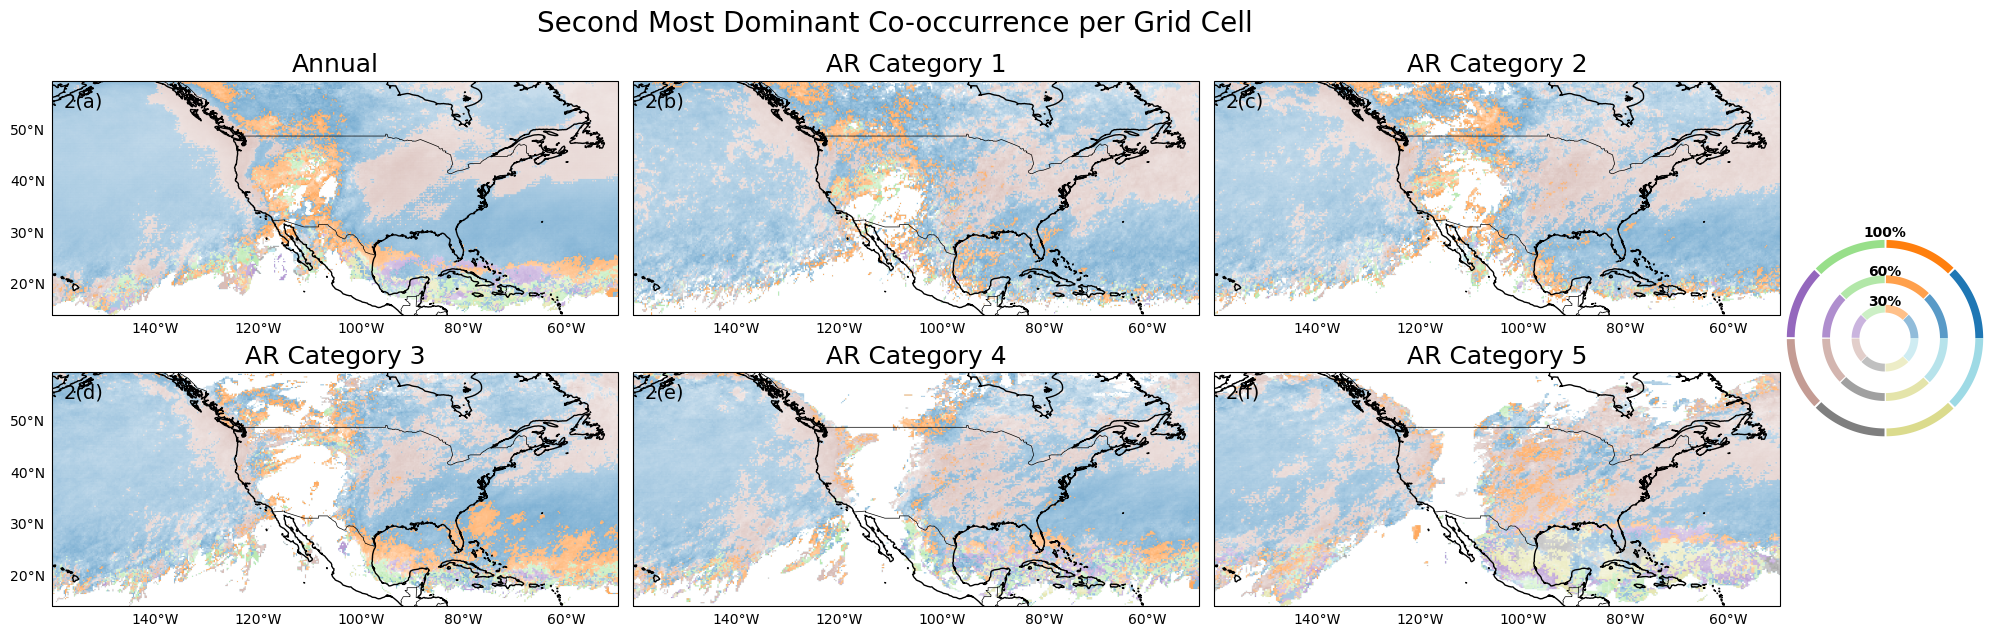

In [33]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
import matplotlib.colors as mcolors
from matplotlib.patches import Patch

# -----------------------------
# CATEGORY LABELS
# -----------------------------
label_index = {
    1: 'AR', 2: 'Front', 3: 'MCS', 4: 'LPS',
    5: 'AR + Front', 6: 'AR + MCS', 7: 'AR + LPS',
    8: 'Front + MCS', 9: 'Front + LPS', 10: 'MCS + LPS',
    11: 'AR + Front + MCS', 12: 'AR + Front + LPS',
    13: 'AR + MCS + LPS', 14: 'Front + MCS + LPS', 15: 'All'
}

# -----------------------------
# LAT/LON LABEL FUNCTION
# -----------------------------
def add_latlon_labels(ax, show_left=True, show_bottom=True):
    gl = ax.gridlines(
        crs=ccrs.PlateCarree(),
        draw_labels=True,
        linewidth=0.0,
        color='none'
    )
    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = show_left
    gl.bottom_labels = show_bottom
    gl.xlabel_style = {'size': 10}
    gl.ylabel_style = {'size': 10}

# -----------------------------
# GLOBAL EXTENT (important!)
# -----------------------------
lon_min = float(second_annual_xr.longitude.min())
lon_max = float(second_annual_xr.longitude.max())
lat_min = float(second_annual_xr.latitude.min())
lat_max = float(second_annual_xr.latitude.max())
extent = [lon_min, lon_max, lat_min, lat_max]

# -----------------------------
# COLORMAP (same logic)
# -----------------------------
all_vals = [second_annual_xr.values]

for cat in [1,2,3,4,5]:
    if cat in second_categories:
        all_vals.append(second_categories[cat].values)

all_vals = np.concatenate([v.flatten() for v in all_vals])
all_vals = all_vals[~np.isnan(all_vals)]

unique_vals = np.unique(all_vals)
existing_labels = {i: label_index[i] for i in unique_vals if i in label_index}

cmap = plt.get_cmap("tab20", len(existing_labels))
bounds = list(existing_labels.keys()) + [max(existing_labels.keys()) + 1]
norm = mcolors.BoundaryNorm(bounds, cmap.N)

# -----------------------------
# FIGURE SETUP
# -----------------------------
fig, axs = plt.subplots(
    2, 3,
    figsize=(18, 6.5),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

axs = axs.ravel()

# -----------------------------
# HELPER FUNCTION
# -----------------------------
def make_rgba(data_xr, alpha_xr):
    alpha_xr = alpha_xr.reindex_like(data_xr)

    Z = data_xr.values
    A = np.clip(alpha_xr.values, 0, 1)
    A = A ** 0.6

    if data_xr.latitude.values[0] > data_xr.latitude.values[-1]:
        Z = np.flipud(Z)
        A = np.flipud(A)

    rgba = cmap(norm(Z))
    rgba[..., -1] = A
    return rgba

# -----------------------------
# PANEL LABELS
# -----------------------------
panel_labels = ['2(a)', '2(b)', '2(c)', '2(d)', '2(e)', '2(f)']

# -----------------------------
# ANNUAL (SECOND DOMINANT)
# -----------------------------
ax = axs[0]

alpha_all = (second_percentage_all / 100.0).clip(0.1, 1.0).fillna(0.0)

rgba = make_rgba(second_annual_xr, alpha_all)

ax.imshow(rgba, origin="lower", extent=extent, transform=ccrs.PlateCarree())
ax.set_aspect('equal')

ax.coastlines()
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.set_title("Annual", fontsize=18)

ax.text(0.02, 0.95, panel_labels[0], transform=ax.transAxes,
        fontsize=14, va='top')

add_latlon_labels(ax, True, True)

# -----------------------------
# AR CATEGORY PANELS
# -----------------------------
categories_to_plot = [1, 2, 3, 4, 5]

for i, cat in enumerate(categories_to_plot, start=1):

    ax = axs[i]

    if cat not in second_categories:
        ax.axis('off')
        continue

    dom = second_categories[cat]
    perc = second_percentages[cat]

    alpha = (perc / 100.0).clip(0.05, 1.0).fillna(0.0)

    rgba = make_rgba(dom, alpha)

    ax.imshow(rgba, origin="lower", extent=extent, transform=ccrs.PlateCarree())
    ax.set_aspect('equal')

    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    ax.set_title(f'AR Category {cat}', fontsize=18)

    ax.text(0.02, 0.95, panel_labels[i], transform=ax.transAxes,
            fontsize=14, va='top')

    add_latlon_labels(
        ax,
        show_left=(i % 3 == 0),
        show_bottom=True
    )

# -----------------------------
# LEGEND
# -----------------------------
legend_elements = []

for cat, lbl in existing_labels.items():
    color = cmap(norm(cat))
    legend_elements.append(
        Patch(facecolor=color, edgecolor='k', label=lbl)
    )
"""
fig.legend(
    handles=legend_elements,
    title="Dominant Category",
    loc="center right",
    bbox_to_anchor=(1.12, 0.65),

    fontsize=11,              # label text
    title_fontsize=13,        # title

    frameon=True,
    borderpad=1.2,            # 🔥 padding inside box (bigger box)
    labelspacing=1.0,         # space between entries
    handlelength=1.8,         # width of color patches
    handleheight=1.2,         # height of color patches
    handletextpad=0.8         # space between patch and text
)
"""
from matplotlib.patches import Polygon, Circle
import numpy as np

# --------------------------------------------------
# ALPHA + COLOR PINWHEEL LEGEND
# --------------------------------------------------

ax_pw = fig.add_axes([0.99, 0.3, 0.12, 0.35])
ax_pw.set_aspect("equal")
ax_pw.axis("off")

ncat = len(existing_labels)

theta = np.linspace(0, 2*np.pi, 300)
theta_edges = np.linspace(0, 2*np.pi, ncat + 1)

# Discrete rings
levels = [
    (0.26, 0.34, 0.49),   # 30%^0.6
    (0.56, 0.64, 0.74),   # 60%^0.6
    (0.92, 1.00, 1.00)    # 100%^0.6
]

for i, cat in enumerate(existing_labels.keys()):
    base_color = cmap(norm(cat))[:3]

    mask = (theta >= theta_edges[i]) & (theta <= theta_edges[i+1])
    th = theta[mask]

    for r0, r1, alpha_val in levels:
        verts = np.vstack([
            np.column_stack([r0*np.cos(th), r0*np.sin(th)]),
            np.column_stack([r1*np.cos(th[::-1]), r1*np.sin(th[::-1])])
        ])

        poly = Polygon(
            verts,
            closed=True,
            facecolor=(*base_color, alpha_val),
            edgecolor="none"
        )
        ax_pw.add_patch(poly)

# --------------------------------------------------
# REFERENCE LABELS ONLY
# --------------------------------------------------
for r, lbl in zip([0.3, 0.6, 1.0], ["30%", "60%", "100%"]):
    ax_pw.text(
        0, r,
        lbl,
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        color="black"
    )

ax_pw.set_xlim(-1.1, 1.1)
ax_pw.set_ylim(-1.1, 1.1)

# --------------------------------------------------
# LABEL (important!)
# --------------------------------------------------
"""
ax_pw.text(
    0, -1.25,
    r"Color = Category" "\n" r"$\alpha = (\mathrm{dominance})^{0.6}$",
    ha="center",
    va="top",
    fontsize=10
)
"""
fig.suptitle(
    "Second Most Dominant Co-occurrence per Grid Cell",
    fontsize=20,
    y=0.98
)
ax_pw.set_xlim(-1.1, 1.1)
ax_pw.set_ylim(-1.1, 1.1)
# limits
ax_pw.set_xlim(-1.1, 1.1)
ax_pw.set_ylim(-1.1, 1.1)
# -----------------------------
# FINALIZE
# -----------------------------
plt.tight_layout()
plt.savefig("Figure3b_corrected.pdf", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
"""
# --------------------------------------------------
# ALPHA + COLOR PINWHEEL LEGEND (α^0.6)
# --------------------------------------------------

ax_pw = fig.add_axes([0.99, 0.3, 0.12, 0.35])
ax_pw.set_aspect("equal")
ax_pw.axis("off")

ncat = len(existing_labels)

theta = np.linspace(0, 2*np.pi, 300)
radii = np.linspace(0.05, 1.0, 120)
theta_edges = np.linspace(0, 2*np.pi, ncat + 1)

for i, cat in enumerate(existing_labels.keys()):
    base_color = cmap(norm(cat))[:3]

    mask = (theta >= theta_edges[i]) & (theta <= theta_edges[i+1])
    th = theta[mask]

    for j in range(len(radii) - 1):
        r0, r1 = radii[j], radii[j+1]

        # MATCH CURRENT SCALING
        alpha_val = r1 ** 0.6

        verts = np.vstack([
            np.column_stack([r0*np.cos(th), r0*np.sin(th)]),
            np.column_stack([r1*np.cos(th[::-1]), r1*np.sin(th[::-1])])
        ])

        poly = Polygon(
            verts,
            closed=True,
            facecolor=(*base_color, alpha_val),
            edgecolor="none"
        )
        ax_pw.add_patch(poly)

# --------------------------------------------------
# REFERENCE RINGS
# --------------------------------------------------
for r, lbl in zip([0.1, 0.5, 1.0], ["10%", "50%", "100%"]):
    circle = Circle(
        (0, 0), r,
        facecolor="none",
        edgecolor="black",
        linestyle="--",
        linewidth=0.8,
        alpha=0.7
    )
    ax_pw.add_patch(circle)

    ax_pw.text(
        0, r,
        lbl,
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )
"""